# Final Python Notebook 1: Data prep
**Author:** Gihan Pasindu

**Reviewer:** Pasan Hirunaka


### Leveraged from Code Reuse Session 1 – Import Libraries and Load Dataset
Importing required libraries and loading the core dataset into memory.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# load data
df = pd.read_csv("loan_approval_data.csv")
df.head()


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


### Leveraged from Code Reuse Session 1 – Basic Dataset Information
Extracting shape, information, and identifying any missing values present in the data.


In [13]:
# check shape
print("shape:", df.shape)

# check info
df.info()
print("\nmissing values:")
print(df.isnull().sum())

# numeric stats
df.describe().transpose()


shape: (58645, 13)
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 5.8 MB

missing values

,count,mean,std,min,25%,50%,75%,max
id,58645.0,29322.000000,16929.497605,0.00,14661.00,29322.00,43983.00,58644.00
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58645.0,69754.717828,61750.913820,-2426900.00,38003.00,62392.00,92716.00,2638778.00


### Plotting Target Variable Distribution
Plotting the distribution of the loan approval status target variable to check class balance.


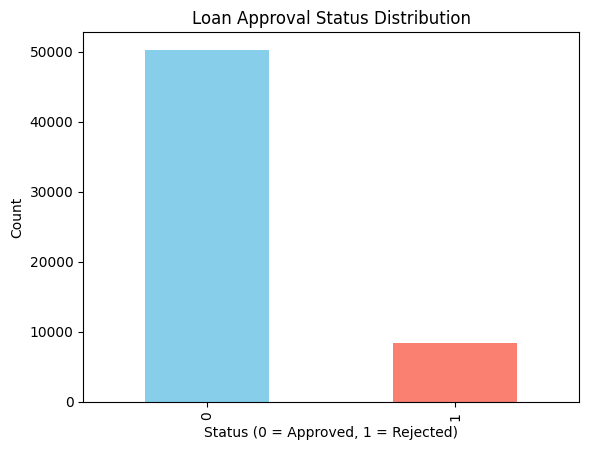

In [14]:
# plot distribution of target variable
df['loan_approval_status'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Loan Approval Status Distribution')
plt.xlabel('Status (0 = Approved, 1 = Rejected)')
plt.ylabel('Count')
plt.show()


### Leveraged from Code Reuse Session 1 – Cleaning and Transforming your data
Missing values imputed using median for continuous variables and mode for categorical variables. Categorical strings encoded into numerical class labels.


In [15]:
# fill missing numerics with median
for col in ['age', 'loan_interest_rate']:
    df[col] = df[col].fillna(df[col].median())

# fill categorical missing with mode
for col in ['payment_default_on_file']:
    df[col] = df[col].fillna(df[col].mode()[0])

# encode categories to numbers
le = LabelEncoder()
for col in ['home_ownership', 'loan_intent', 'payment_default_on_file']:
    df[col] = le.fit_transform(df[col])

# double check no missing values
print("missing left:", df.isnull().sum().sum())
df.head()


missing left: 0


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0,-2426900
1,53756,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0,-111739
2,42205,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0,-89000
3,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0,35000
4,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0,35000


### Leveraged from Tutorial 6: Separating your clean data into two sets
The clean dataset is divided into two separate subsets specifically for classification and regression tasks requirement.


In [16]:
# 1. classfication dataset (drop id and max loan)
df_class = df.drop(['id', 'max_allowed_loan'], axis=1)
df_class.to_csv('loan_approval_status_data.csv', index=False)
print("classification data saved! shape:", df_class.shape)

# 2. regression dataset (only approved ones, drop id and status)
df_reg = df[df['loan_approval_status'] == 0].copy()
df_reg.drop(['id', 'loan_approval_status'], axis=1, inplace=True)
df_reg.to_csv('loan_max_amount_data.csv', index=False)
print("regression data saved! shape:", df_reg.shape)


classification data saved! shape: (58645, 11)
regression data saved! shape: (50295, 11)
